# EXP3-C · Logistic Regression + CatBoost (GPU)

Trains **Logistic Regression** and **CatBoost** (CUDA GPU) with 2-stage optimization across 6 sampling methods.  
Run in parallel with EXP3-A and EXP3-B.

In [30]:
# Optional install (uncomment if needed), then restart kernel once.
%pip install -q numpy pandas scipy scikit-learn joblib venn-abers seaborn matplotlib imbalanced-learn torch shap lime
%pip install -q cuml-cu13 --extra-index-url=https://pypi.nvidia.com

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [31]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [32]:
import json
import random
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, loguniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)

xgb_available = True
cat_available = True
venn_available = True
torch_available = True
torch_cuda_available = False
cuml_available = True

try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    cat_available = False
    CatBoostClassifier = None

try:
    from venn_abers import VennAbers
except Exception:
    venn_available = False
    VennAbers = None

try:
    import torch
    torch_cuda_available = bool(torch.cuda.is_available())
except Exception:
    torch_available = False

try:
    from cuml.ensemble import RandomForestClassifier as cuRFClassifier
except Exception:
    cuml_available = False
    cuRFClassifier = None

print({
    'xgboost': xgb_available,
    'catboost': cat_available,
    'venn_abers': venn_available,
    'torch': torch_available,
    'torch_cuda': torch_cuda_available,
    'cuml_rf': cuml_available,
})

{'xgboost': True, 'catboost': True, 'venn_abers': True, 'torch': True, 'torch_cuda': True, 'cuml_rf': True}


In [33]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'gpuV2.2.1.1/Main_2015_GPU_RF_XGB_CAT_RIGOROUS_OPT_exp2.ipynb_rf_xgb_cat_exp2_artifacts'
MODEL_DIR = ARTIFACT_DIR / 'models'

for p in [ARTIFACT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET2015_CANDIDATES = [
    PROJECT_ROOT / 'Datasets2015',
    PROJECT_ROOT.parent / 'Datasets2015',
]

AUTO_MERGED_DATA_PATH = None
DATA_CANDIDATES = [
    PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_leftjoin.csv',
]

TARGET_CANDIDATES = ['hypertension', 'htn', 'target', 'label', 'outcome']
COLLINEARITY_CUTOFF = 0.70

STAGE1_EPOCHS = 120
STAGE2_EPOCHS = 300
FINAL_EPOCHS = 900

STAGE1_TRIALS_PER_MODEL = 180
STAGE2_REFINEMENTS_PER_TOP_CONFIG = 24
TOP_K_STAGE1 = 8
TOP_K_STAGE2 = 3
CV_FOLDS_STAGE1 = 5
CV_FOLDS_STAGE2 = 6

USE_GPU_WHEN_AVAILABLE = True
N_JOBS = -1

print('Artifacts:', ARTIFACT_DIR)

Artifacts: /workspace/Thesis-part-2/gpuV2.2.1.1/Main_2015_GPU_RF_XGB_CAT_RIGOROUS_OPT_exp2.ipynb_rf_xgb_cat_exp2_artifacts


In [34]:
def _normalize_join_columns(df_in):
    rename_map = {}
    col_lc = {c.lower(): c for c in df_in.columns}
    for key in ['hhnum', 'member_code']:
        if key in col_lc and col_lc[key] != key:
            rename_map[col_lc[key]] = key
    return df_in.rename(columns=rename_map)

def _find_anthropometric_dataset_path():
    for base in DATASET2015_CANDIDATES:
        anthro_dir = base / 'Anthropometric'
        if not anthro_dir.exists():
            continue

        csv_paths = sorted([p for p in anthro_dir.glob('*.csv') if 'dictionary' not in p.name.lower()])
        preferred = [
            p for p in csv_paths
            if ('data-set' in p.name.lower()) or ('dataset' in p.name.lower())
        ]
        for p in preferred + csv_paths:
            return p
    return None

def _prepare_merged_with_anthro(base_path):
    if not base_path.exists():
        return None

    try:
        base_df = pd.read_csv(base_path)
    except Exception:
        return None

    anthro_tokens = ['weight', 'height', 'waist', 'hip', 'bmi', 'whr']
    has_anthro = any(any(tok in c.lower() for tok in anthro_tokens) for c in base_df.columns)
    if has_anthro:
        return base_path

    anthro_path = _find_anthropometric_dataset_path()
    if anthro_path is None:
        return None

    try:
        anthro_df = pd.read_csv(anthro_path)
    except Exception:
        return None

    base_df = _normalize_join_columns(base_df)
    anthro_df = _normalize_join_columns(anthro_df)

    join_keys = [k for k in ['hhnum', 'member_code'] if k in base_df.columns and k in anthro_df.columns]
    if not join_keys:
        return None

    anthro_df = anthro_df.drop_duplicates(subset=join_keys, keep='first')

    overlap = [c for c in anthro_df.columns if c in base_df.columns and c not in join_keys]
    if overlap:
        anthro_df = anthro_df.rename(columns={c: f'{c}_anthro' for c in overlap})

    merged_df = base_df.merge(anthro_df, on=join_keys, how='left')
    out_path = PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv'
    merged_df.to_csv(out_path, index=False)

    print(f'Prepared anthropometric-augmented dataset: {out_path}')
    print(f'  source merged file: {base_path}')
    print(f'  source anthropometric file: {anthro_path}')
    print(f'  join keys: {join_keys}')
    return out_path

def resolve_data_path(candidates):
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'No dataset found. Checked: {candidates}')

def infer_target_column(df, candidates):
    lc = {c.lower(): c for c in df.columns}
    for t in candidates:
        if t.lower() in lc:
            return lc[t.lower()]
    for c in df.columns:
        c_lc = c.lower()
        if any(t.lower() in c_lc for t in candidates):
            return c
    return None

def infer_bp_columns(df):
    sbp_aliases = ['ave_sbp', 'sbp', 'systolic', 'sysbp', 's_bp']
    dbp_aliases = ['ave_dbp', 'dbp', 'diastolic', 'diabp', 'd_bp']

    lc = {c.lower(): c for c in df.columns}

    sbp_col = None
    for a in sbp_aliases:
        if a in lc:
            sbp_col = lc[a]
            break
    if sbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in sbp_aliases):
                sbp_col = c
                break

    dbp_col = None
    for a in dbp_aliases:
        if a in lc:
            dbp_col = lc[a]
            break
    if dbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in dbp_aliases):
                dbp_col = c
                break

    return sbp_col, dbp_col

def find_first_column_case_insensitive(columns, candidates):
    lc = {c.lower(): c for c in columns}
    for cand in candidates:
        cand_lc = cand.lower()
        if cand_lc in lc:
            return lc[cand_lc]
    for c in columns:
        c_lc = c.lower()
        if any(cand.lower() in c_lc for cand in candidates):
            return c
    return None

def to_numeric_clean(series):
    s = pd.to_numeric(series, errors='coerce')
    return s.where(~s.isin([9, 99, 888888, 999999]), np.nan)

def build_smoking_level_feature(df_in):
    used_cols = []
    smoking_level_col = find_first_column_case_insensitive(df_in.columns, ['smoking_level'])
    smoke_status_col = find_first_column_case_insensitive(df_in.columns, ['smoke_status'])
    current_smoking_col = find_first_column_case_insensitive(df_in.columns, ['current_smoking', 'currentsmoking'])
    ever_smoke_col = find_first_column_case_insensitive(df_in.columns, ['ever_smk'])

    if smoking_level_col is not None:
        s = to_numeric_clean(df_in[smoking_level_col]).clip(lower=0, upper=3)
        used_cols.append(smoking_level_col)
        return s.astype(float), sorted(set(used_cols))

    idx = df_in.index
    smoke = pd.Series(np.nan, index=idx, dtype=float)

    if smoke_status_col is not None:
        status = to_numeric_clean(df_in[smoke_status_col])
        used_cols.append(smoke_status_col)
        smoke.loc[status == 0] = 0
        smoke.loc[status == 2] = 1
        smoke.loc[status == 1] = 2
        if current_smoking_col is not None:
            current = to_numeric_clean(df_in[current_smoking_col])
            used_cols.append(current_smoking_col)
            smoke.loc[(status == 1) & (current == 3)] = 3
        return smoke.astype(float), sorted(set(used_cols))

    if current_smoking_col is not None:
        current = to_numeric_clean(df_in[current_smoking_col])
        used_cols.append(current_smoking_col)
        smoke.loc[current == 0] = 0
        smoke.loc[current.isin([1, 2])] = 2
        smoke.loc[current == 3] = 3
        if ever_smoke_col is not None:
            ever = to_numeric_clean(df_in[ever_smoke_col])
            used_cols.append(ever_smoke_col)
            smoke.loc[(current == 0) & (ever > 0)] = 1
        return smoke.astype(float), sorted(set(used_cols))

    if ever_smoke_col is not None:
        ever = to_numeric_clean(df_in[ever_smoke_col])
        used_cols.append(ever_smoke_col)
        smoke.loc[ever == 0] = 0
        smoke.loc[ever > 0] = 1
        return smoke.astype(float), sorted(set(used_cols))

    return None, []

def build_alcohol_level_feature(df_in):
    used_cols = []
    alcohol_level_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_level'])
    alcohol_status_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_status'])
    alcohol_ever_col = find_first_column_case_insensitive(df_in.columns, ['alcohol'])
    current_alcohol_col = find_first_column_case_insensitive(df_in.columns, ['con_alcohol'])
    drink30_col = find_first_column_case_insensitive(df_in.columns, ['drnk_30days'])
    binge_col = find_first_column_case_insensitive(df_in.columns, ['binge_drink', 'binge_drinking'])

    if alcohol_level_col is not None:
        a = to_numeric_clean(df_in[alcohol_level_col]).clip(lower=0, upper=3)
        used_cols.append(alcohol_level_col)
        return a.astype(float), sorted(set(used_cols))

    idx = df_in.index
    alcohol = pd.Series(np.nan, index=idx, dtype=float)

    if alcohol_status_col is not None:
        status = to_numeric_clean(df_in[alcohol_status_col])
        used_cols.append(alcohol_status_col)
        alcohol.loc[status == 0] = 0
        alcohol.loc[status == 2] = 1
        alcohol.loc[status == 1] = 2
        if binge_col is not None:
            binge = to_numeric_clean(df_in[binge_col])
            used_cols.append(binge_col)
            alcohol.loc[(status == 1) & (binge == 1)] = 3
        return alcohol.astype(float), sorted(set(used_cols))

    alcohol.loc[:] = 0
    if alcohol_ever_col is not None:
        ever = to_numeric_clean(df_in[alcohol_ever_col])
        used_cols.append(alcohol_ever_col)
        alcohol.loc[ever > 0] = 1
    if current_alcohol_col is not None:
        current = to_numeric_clean(df_in[current_alcohol_col])
        used_cols.append(current_alcohol_col)
        alcohol.loc[current == 1] = np.maximum(alcohol.loc[current == 1], 2)
    if drink30_col is not None:
        d30 = to_numeric_clean(df_in[drink30_col])
        used_cols.append(drink30_col)
        alcohol.loc[d30 == 1] = np.maximum(alcohol.loc[d30 == 1], 2)
    if binge_col is not None:
        binge = to_numeric_clean(df_in[binge_col])
        used_cols.append(binge_col)
        alcohol.loc[binge == 1] = 3

    if used_cols:
        return alcohol.astype(float), sorted(set(used_cols))

    return None, []

def build_bmi_feature(df_in):
    weight_col = find_first_column_case_insensitive(df_in.columns, ['weight'])
    height_col = find_first_column_case_insensitive(df_in.columns, ['height'])
    if weight_col is None or height_col is None:
        return None, []
    w = pd.to_numeric(df_in[weight_col], errors='coerce')
    h = pd.to_numeric(df_in[height_col], errors='coerce')
    h_m = h.copy()
    if pd.notna(h_m.median(skipna=True)) and float(h_m.median(skipna=True)) > 3.0:
        h_m = h_m / 100.0
    bmi = w / (h_m ** 2)
    bmi = bmi.replace([np.inf, -np.inf], np.nan)
    return bmi.astype(float), [weight_col, height_col]

def build_whr_feature(df_in):
    waist_col = find_first_column_case_insensitive(df_in.columns, ['waist'])
    hip_col = find_first_column_case_insensitive(df_in.columns, ['hip'])
    if waist_col is None or hip_col is None:
        return None, []
    waist = pd.to_numeric(df_in[waist_col], errors='coerce')
    hip = pd.to_numeric(df_in[hip_col], errors='coerce').replace(0, np.nan)
    whr = (waist / hip).replace([np.inf, -np.inf], np.nan)
    return whr.astype(float), [waist_col, hip_col]

In [35]:
AUTO_MERGED_DATA_PATH = None
for merged_candidate in [
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_leftjoin.csv',
]:
    AUTO_MERGED_DATA_PATH = _prepare_merged_with_anthro(merged_candidate)
    if AUTO_MERGED_DATA_PATH is not None:
        break

effective_candidates = [
    AUTO_MERGED_DATA_PATH,
    *DATA_CANDIDATES,
]
effective_candidates = [p for p in effective_candidates if p is not None]

data_path = resolve_data_path(effective_candidates)
df = pd.read_csv(data_path)
target_col = infer_target_column(df, TARGET_CANDIDATES)
TARGET_DEFINED_FROM_BP = False
TARGET_SOURCE_COLUMNS = []

if target_col is None:
    sbp_col, dbp_col = infer_bp_columns(df)
    if sbp_col is not None and dbp_col is not None:
        sbp = pd.to_numeric(df[sbp_col], errors='coerce')
        dbp = pd.to_numeric(df[dbp_col], errors='coerce')
        df['Hypertension'] = (((sbp >= 130) | (dbp >= 80)).fillna(False)).astype(int)
        target_col = 'Hypertension'
        TARGET_DEFINED_FROM_BP = True
        TARGET_SOURCE_COLUMNS = [sbp_col, dbp_col]
        print(f'Target column created from: {sbp_col}, {dbp_col}')
    else:
        raise ValueError('Could not infer target and could not derive Hypertension from SBP/DBP (130/80 OR rule).')

df = df.dropna(subset=[target_col]).copy()
y_raw = df[target_col]
if y_raw.nunique() != 2:
    raise ValueError(f'Target must be binary. Found {y_raw.nunique()} classes.')

if y_raw.dtype == 'O':
    y = pd.Series(LabelEncoder().fit_transform(y_raw.astype(str)), index=y_raw.index, name=target_col)
else:
    y = pd.Series(y_raw.astype(int), index=y_raw.index, name=target_col)

X = df.drop(columns=[target_col]).copy()

smoking_feature, smoking_sources = build_smoking_level_feature(X)
if smoking_feature is not None:
    X['fe_smoking_level'] = smoking_feature

alcohol_feature, alcohol_sources = build_alcohol_level_feature(X)
if alcohol_feature is not None:
    X['fe_alcohol_level'] = alcohol_feature

bmi_feature, bmi_sources = build_bmi_feature(X)
if bmi_feature is not None:
    X['bmi'] = bmi_feature

whr_feature, whr_sources = build_whr_feature(X)
if whr_feature is not None:
    X['whr'] = whr_feature

behavior_raw_candidates = [
    'current_smoking', 'currentsmoking', 'ever_smk', 'smoke_status', 'smoking_level',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drink', 'binge_drinking', 'alcohol_level',
]
x_lc = {c.lower(): c for c in X.columns}
behavior_drop = sorted({x_lc[c.lower()] for c in behavior_raw_candidates if c.lower() in x_lc})
if behavior_drop:
    X = X.drop(columns=behavior_drop, errors='ignore')

anthro_source_drop = sorted({
    c for c in set((bmi_sources or []) + (whr_sources or []))
    if c in X.columns and c.lower() not in {'bmi', 'whr'}
})
if anthro_source_drop:
    X = X.drop(columns=anthro_source_drop, errors='ignore')

NON_REMOVABLE_BASE_ALIASES = ['age', 'sex']

manual_non_predictive = [
    'regcode', 'provcode', 'provhuc', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'fwgt', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'ms_psucode', 'enns_year', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'hhnum', 'member_code',
    'ave_sbp', 'ave_dbp', 'sbp', 'dbp', 'systolic', 'diastolic', 'sysbp', 'diabp',
    'blood_pressure',
    'height', 'weight', 'waist', 'hip',
]
x_lc = {c.lower(): c for c in X.columns}
manual_drop = sorted({x_lc[c.lower()] for c in manual_non_predictive if c.lower() in x_lc})

protected_base_cols = []
for col in X.columns:
    col_lc = col.lower()
    if any(alias in col_lc for alias in NON_REMOVABLE_BASE_ALIASES):
        protected_base_cols.append(col)
protected_base_cols = sorted(set(protected_base_cols))

if manual_drop:
    protected_drop = [c for c in manual_drop if c in protected_base_cols]
    if protected_drop:
        print('Manual-drop protection triggered for non-removable base features:', protected_drop)
    manual_drop = [c for c in manual_drop if c not in protected_base_cols]
    X = X.drop(columns=manual_drop, errors='ignore')

base_removed_non_removable = []
for alias in NON_REMOVABLE_BASE_ALIASES:
    if not any(alias in c.lower() for c in X.columns):
        base_removed_non_removable.append(alias)

RETRAIN_REQUIRED_NON_REMOVABLE = len(base_removed_non_removable) > 0

print(f'Loaded: {data_path}')
print(f'Auto merged dataset: {AUTO_MERGED_DATA_PATH}')
print(f'Target: {target_col}')
print(f'Target defined from BP fallback: {TARGET_DEFINED_FROM_BP}')
print(f'Raw rows: {len(df)}')
print(f'Features after manual preprocessing: {X.shape[1]}')
print(f'Manual dropped columns: {len(manual_drop)}')
print(f'Behavior raw dropped columns: {len(behavior_drop)}')
print(f'Anthropometric source dropped columns: {len(anthro_source_drop)}')
print('Protected non-removable base columns:', protected_base_cols)
print('Missing non-removable base aliases after base preprocessing:', base_removed_non_removable)
print('Class balance:', y.value_counts(normalize=True).to_dict())

Prepared anthropometric-augmented dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
  source merged file: /workspace/Thesis-part-2/merged_clinical_dietary_leftjoin.csv
  source anthropometric file: /workspace/Thesis-part-2/Datasets2015/Anthropometric/Jonathan Ralph_Baes_2026-03-26141834_data-set_anthrop.csv
  join keys: ['hhnum', 'member_code']
Target column created from: Ave_SBP, Ave_DBP
Loaded: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Auto merged dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Target: Hypertension
Target defined from BP fallback: True
Raw rows: 151189
Features after manual preprocessing: 57
Manual dropped columns: 14
Behavior raw dropped columns: 9
Anthropometric source dropped columns: 4
Protected non-removable base columns: ['age', 'age_anthro', 'agemos', 'sex', 'sex_anthro']
Missing non-removable base aliases after base preprocessing: []
Class balance: {0: 0.6638379776306478, 1: 

In [36]:
# ── EXP3 · Imports & Setup ───────────────────────────────────────────────────
# Inherits: PROJECT_ROOT, X, y — defined by earlier cells in this notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from copy import deepcopy

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, log_loss, make_scorer,
)
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import SMOTE, SMOTENC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from venn_abers import VennAbers
import shap
import lime.lime_tabular

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

E3_SEED = 42
np.random.seed(E3_SEED)

E3_DIR = PROJECT_ROOT / 'exp3_logreg_cat'
(E3_DIR / 'models').mkdir(parents=True, exist_ok=True)
(E3_DIR / 'plots').mkdir(parents=True, exist_ok=True)

SAMPLING_METHODS = ['base', 'smote', 'smotenc', 'cw', 'smotecw', 'smotencw']
MODEL_NAMES      = ['logreg', 'catboost']
CAL_METHODS      = ['base', 'platt', 'isotonic', 'venn_abers']
CW_SAMPLINGS     = {'cw', 'smotecw', 'smotencw'}   # variants that activate class-weight

# RandomizedSearchCV iterations per model (slower models get fewer)
N_ITER_MAP = {
    'logreg': 10, 'knn': 10, 'adaboost': 10,
    'catboost': 5, 'xgboost': 5, 'randomforest': 10,
}

SEARCH_SPACES = {
    'logreg': {
        'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    },
    'knn': {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights':     ['uniform', 'distance'],
    },
    'adaboost': {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    },
    'catboost': {
        'depth':         [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'iterations':    [100, 200, 300],
    },
    'xgboost': {
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'n_estimators':  [100, 200, 300],
    },
    'randomforest': {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [None, 5, 10, 15],
        'min_samples_leaf': [1, 2, 5],
    },
}

print("EXP3 setup complete.")
print("Artifact directory:", E3_DIR)


EXP3 setup complete.
Artifact directory: /workspace/Thesis-part-2/exp3_logreg_cat


In [37]:
# ── EXP3 · 3-Way Split + Column Detection ───────────────────────────────────
# 60 % Train | 20 % Calibration | 20 % Test  (stratified)

X_e3_tr, X_e3_tmp, y_e3_tr, y_e3_tmp = train_test_split(
    X, y, test_size=0.40, random_state=E3_SEED, stratify=y
)
X_e3_cal, X_e3_te, y_e3_cal, y_e3_te = train_test_split(
    X_e3_tmp, y_e3_tmp, test_size=0.50, random_state=E3_SEED, stratify=y_e3_tmp
)

y_e3_tr  = np.asarray(y_e3_tr,  dtype=int)
y_e3_cal = np.asarray(y_e3_cal, dtype=int)
y_e3_te  = np.asarray(y_e3_te,  dtype=int)

# Column types detected on training set
e3_num_cols = X_e3_tr.select_dtypes(include=[np.number]).columns.tolist()
e3_cat_cols = [c for c in X_e3_tr.columns if c not in e3_num_cols]

print(pd.DataFrame({
    'Split': ['Train', 'Cal', 'Test'],
    'N':     [len(y_e3_tr), len(y_e3_cal), len(y_e3_te)],
    'Pos %': [f"{y_e3_tr.mean()*100:.1f}", f"{y_e3_cal.mean()*100:.1f}", f"{y_e3_te.mean()*100:.1f}"],
}).to_string(index=False))
print(f"\nNumeric features : {len(e3_num_cols)}")
print(f"Categorical      : {len(e3_cat_cols)}")


Split     N Pos %
Train 90713  33.6
  Cal 30238  33.6
 Test 30238  33.6

Numeric features : 57
Categorical      : 0


In [46]:
# ── EXP3 · Helper Functions ──────────────────────────────────────────────────

# ── OHE factory ───────────────────────────────────────────────────────────────
def _e3_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

# ── Imputation ────────────────────────────────────────────────────────────────
def e3_fit_imputers(X_tr, num_cols, cat_cols):
    knn = KNNImputer(n_neighbors=5)
    knn.fit(X_tr[num_cols] if num_cols else pd.DataFrame())
    cat = None
    if cat_cols:
        cat = SimpleImputer(strategy='most_frequent')
        cat.fit(X_tr[cat_cols])
    return knn, cat

def e3_impute(knn, cat_imp, X, num_cols, cat_cols):
    frames = []
    if num_cols:
        frames.append(pd.DataFrame(
            knn.transform(X[num_cols]), columns=num_cols, index=X.index))
    if cat_cols and cat_imp is not None:
        frames.append(pd.DataFrame(
            cat_imp.transform(X[cat_cols]), columns=cat_cols, index=X.index))
    return pd.concat(frames, axis=1) if frames else pd.DataFrame(index=X.index)

# ── Scale + OHE ───────────────────────────────────────────────────────────────
def e3_fit_enc_scaler(X_imp, num_cols, cat_cols):
    scaler = StandardScaler()
    ohe    = None
    feat_names = list(num_cols)
    if num_cols:
        scaler.fit(X_imp[num_cols])
    if cat_cols:
        ohe = _e3_ohe()
        ohe.fit(X_imp[cat_cols].astype(str))
        feat_names += ohe.get_feature_names_out(cat_cols).tolist()
    return scaler, ohe, feat_names

def e3_encode_scale(scaler, ohe, X_imp, num_cols, cat_cols):
    parts = []
    if num_cols:
        parts.append(scaler.transform(X_imp[num_cols]))
    if cat_cols and ohe is not None:
        parts.append(ohe.transform(X_imp[cat_cols].astype(str)))
    return np.hstack(parts) if parts else np.empty((len(X_imp), 0))

# ── Sampling ──────────────────────────────────────────────────────────────────
def e3_get_sampled_train(X_tr_imp, y_tr, sampling, scaler, ohe, num_cols, cat_cols, seed=42):
    min_cls = int(np.bincount(np.asarray(y_tr, dtype=int)).min())
    k_nb    = max(1, min(5, min_cls - 1))

    if sampling in ('base', 'cw'):
        return e3_encode_scale(scaler, ohe, X_tr_imp, num_cols, cat_cols), np.asarray(y_tr).copy()

    if sampling in ('smote', 'smotecw'):
        Xp = e3_encode_scale(scaler, ohe, X_tr_imp, num_cols, cat_cols)
        return SMOTE(random_state=seed, k_neighbors=k_nb).fit_resample(Xp, y_tr)

    # SMOTENC / SMOTENCW
    if not cat_cols:
        Xp = e3_encode_scale(scaler, ohe, X_tr_imp, num_cols, cat_cols)
        return SMOTE(random_state=seed, k_neighbors=k_nb).fit_resample(Xp, y_tr)

    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat_ord  = oe.fit_transform(X_tr_imp[cat_cols].astype(str))
    X_num_arr  = X_tr_imp[num_cols].values if num_cols else np.empty((len(X_tr_imp), 0))
    X_combined = np.hstack([X_num_arr, X_cat_ord])
    cat_idx    = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

    X_res, y_res = SMOTENC(
        categorical_features=cat_idx, random_state=seed, k_neighbors=k_nb
    ).fit_resample(X_combined, y_tr)

    df_num = pd.DataFrame(X_res[:, :len(num_cols)], columns=num_cols) if num_cols else pd.DataFrame()
    X_cat_labels = oe.inverse_transform(np.clip(np.round(X_res[:, len(num_cols):]), 0, None).astype(float))
    df_cat = pd.DataFrame(X_cat_labels, columns=cat_cols)
    X_res_imp = pd.concat([df_num, df_cat], axis=1)
    return e3_encode_scale(scaler, ohe, X_res_imp, num_cols, cat_cols), y_res

# ── ECE ───────────────────────────────────────────────────────────────────────
def e3_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob), 1e-9, 1 - 1e-9)
    bins   = np.linspace(0, 1, n_bins + 1)
    idx    = np.digitize(y_prob, bins) - 1
    ece    = 0.0
    for i in range(n_bins):
        m = idx == i
        if m.sum() == 0:
            continue
        ece += m.mean() * abs(y_true[m].mean() - y_prob[m].mean())
    return float(ece)

# ── Metric pack ───────────────────────────────────────────────────────────────
def e3_metrics(y_true, y_prob, thr=0.5):
    yp = (np.asarray(y_prob) >= thr).astype(int)
    return dict(
        accuracy  = accuracy_score(y_true, yp),
        recall    = recall_score(y_true, yp, zero_division=0),
        precision = precision_score(y_true, yp, zero_division=0),
        f1        = f1_score(y_true, yp, zero_division=0),
        auc       = roc_auc_score(y_true, y_prob),
        logloss   = log_loss(y_true, y_prob),
        ece       = e3_ece(y_true, y_prob),
    )

# ── Calibration helpers ───────────────────────────────────────────────────────
def e3_fit_calibrator(method, p_cal, y_cal):
    if method == 'base':    return None
    if method == 'platt':
        lr = LogisticRegression(max_iter=3000, random_state=42)
        lr.fit(p_cal.reshape(-1, 1), y_cal)
        return lr
    if method == 'isotonic':
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(p_cal, y_cal)
        return iso
    if method == 'venn_abers':
        va = VennAbers()
        va.fit(np.column_stack([1.0 - p_cal, p_cal]), y_cal)
        return va
    raise ValueError(method)

def e3_apply_calibrator(method, calibrator, p_eval):
    p = np.clip(np.asarray(p_eval), 1e-9, 1 - 1e-9)
    if method == 'base' or calibrator is None:
        return p
    if method == 'platt':
        return np.clip(calibrator.predict_proba(p.reshape(-1, 1))[:, 1], 1e-9, 1 - 1e-9)
    if method == 'isotonic':
        return np.clip(calibrator.predict(p), 1e-9, 1 - 1e-9)
    if method == 'venn_abers':
        _, p1 = calibrator.predict_proba(np.column_stack([1.0 - p, p]))
        p1 = np.asarray(p1)
        return np.clip(p1[:, 1] if p1.ndim == 2 else p1.reshape(-1), 1e-9, 1 - 1e-9)
    raise ValueError(method)

# ── Combined accuracy + recall scorer (legacy, kept for compat) ───────────────
def _acc_recall(y_true, y_pred):
    return 0.5 * accuracy_score(y_true, y_pred) + \
           0.5 * recall_score(y_true, y_pred, zero_division=0)
e3_scorer = make_scorer(_acc_recall)

# ══════════════════════════════════════════════════════════════════════════════
# 2-STAGE OPTIMIZATION HELPERS
# ══════════════════════════════════════════════════════════════════════════════

# ── Model builder with epoch_budget control ───────────────────────────────────
def e3_build_model_for_search(model_name, params, use_cw, y_sample, epoch_budget, seed=42):
    """Build model using hyperparams dict + epoch_budget (n_estimators / iterations)."""
    n_pos = int(np.asarray(y_sample).sum())
    n_neg = len(y_sample) - n_pos
    pos_w = float(n_neg) / max(n_pos, 1)
    p     = deepcopy(params)
    use_gpu = bool(USE_GPU_WHEN_AVAILABLE and torch_cuda_available)

    if model_name == 'logreg':
        return LogisticRegression(
            C=float(p.get('C', 1.0)),
            solver=p.get('solver', 'lbfgs'),
            max_iter=1000, random_state=seed,
            class_weight='balanced' if use_cw else None)

    if model_name == 'knn':
        return KNeighborsClassifier(
            n_neighbors=max(1, int(p.get('n_neighbors', 7))),
            weights=p.get('weights', 'uniform'),
            metric=p.get('metric', 'euclidean'),
            n_jobs=1)

    if model_name == 'adaboost':
        base_d = max(1, int(round(p.get('base_depth', 1))))
        base   = DecisionTreeClassifier(
            max_depth=base_d, random_state=seed,
            class_weight='balanced' if use_cw else None)
        kwargs = dict(
            n_estimators=max(10, int(round(p.get('n_estimators', epoch_budget)))),
            learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
            random_state=seed)
        try:
            return AdaBoostClassifier(estimator=base, **kwargs)
        except TypeError:
            return AdaBoostClassifier(base_estimator=base, **kwargs)

    if model_name == 'catboost':
        kwargs = dict(
            iterations=int(epoch_budget),
            learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
            depth=max(1, int(round(p.get('depth', 6)))),
            l2_leaf_reg=max(1e-4, float(p.get('l2_leaf_reg', 3.0))),
            random_strength=max(1e-4, float(p.get('random_strength', 1.0))),
            loss_function='Logloss', eval_metric='Logloss',
            random_seed=seed, verbose=0,
        )
        if use_cw:  kwargs['auto_class_weights'] = 'Balanced'
        if use_gpu: kwargs['task_type'] = 'GPU'; kwargs['devices'] = '0'
        return CatBoostClassifier(**kwargs)

    if model_name == 'xgboost':
        return XGBClassifier(
            n_estimators=int(epoch_budget),
            learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
            max_depth=max(1, int(round(p.get('max_depth', 5)))),
            subsample=float(np.clip(p.get('subsample', 0.8), 0.1, 1.0)),
            colsample_bytree=float(np.clip(p.get('colsample_bytree', 0.8), 0.1, 1.0)),
            min_child_weight=max(1, int(round(p.get('min_child_weight', 1)))),
            gamma=max(0.0, float(p.get('gamma', 0.0))),
            reg_lambda=max(1e-4, float(p.get('reg_lambda', 1.0))),
            objective='binary:logistic', eval_metric='logloss',
            random_state=seed, tree_method='hist',
            device='cuda' if use_gpu else 'cpu',
            verbosity=0,
            scale_pos_weight=pos_w if use_cw else 1.0,
        )

    if model_name == 'randomforest':
        raw_mf = p.get('max_features', 'sqrt')
        if isinstance(raw_mf, float):
            raw_mf = float(np.clip(raw_mf, 0.01, 1.0))
        return RandomForestClassifier(
            n_estimators=int(epoch_budget),
            max_depth=p.get('max_depth', None),
            min_samples_split=max(2, int(round(p.get('min_samples_split', 2)))),
            min_samples_leaf=max(1, int(round(p.get('min_samples_leaf', 1)))),
            max_features=raw_mf,
            random_state=seed, n_jobs=-1,
            class_weight='balanced_subsample' if use_cw else None,
        )
    raise ValueError(f"Unknown model: {model_name}")

# ── Candidate refinement (local perturbation of top-K params) ────────────────
def e3_refine_candidates(base_params_list, n_refine=4, seed=42):
    """Locally perturb each base config ±30 % to generate refined candidates."""
    rng  = np.random.RandomState(seed)
    out  = []
    for b in base_params_list:
        out.append(deepcopy(b))
        for _ in range(n_refine):
            c = {}
            for k, v in b.items():
                if isinstance(v, (int, np.integer)):
                    c[k] = max(1, int(round(v * rng.uniform(0.7, 1.3))))
                elif isinstance(v, (float, np.floating)):
                    c[k] = max(1e-7, float(v * rng.uniform(0.7, 1.3)))
                else:
                    c[k] = v   # strings, None — keep as-is
            out.append(c)
    seen, unique = set(), []
    for item in out:
        key = json.dumps(item, sort_keys=True, default=str)
        if key not in seen:
            seen.add(key)
            unique.append(item)
    return unique

# ── In-fold CV evaluation with sampling (no data leakage) ────────────────────
def e3_evaluate_params_cv(model_name, params, sampling,
                           X_tr_imp, y_tr, epoch_budget,
                           n_splits=3, seed=42):
    """
    K-fold CV with in-fold sampling (scaler+OHE fit on each fold independently).
    Objective: 0.60 * accuracy + 0.40 * recall (mirrors the original notebook).
    """
    use_cw   = sampling in CW_SAMPLINGS
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    thr_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)
    fold_rows = []
    y_arr = np.asarray(y_tr, dtype=int)

    for fold_i, (tr_idx, va_idx) in enumerate(splitter.split(X_tr_imp, y_arr), start=1):
        Xf_tr = X_tr_imp.iloc[tr_idx]
        Xf_va = X_tr_imp.iloc[va_idx]
        yf_tr = y_arr[tr_idx]
        yf_va = y_arr[va_idx]

        # ── fit scaler+OHE on this fold's train only (no leakage) ────────────
        f_sc, f_ohe, _ = e3_fit_enc_scaler(Xf_tr, e3_num_cols, e3_cat_cols)

        # ── apply sampling to fold-train ──────────────────────────────────────
        Xf_tr_s, yf_tr_s = e3_get_sampled_train(
            Xf_tr, yf_tr, sampling, f_sc, f_ohe, e3_num_cols, e3_cat_cols, seed=seed)
        yf_tr_s = np.asarray(yf_tr_s, dtype=int)

        # ── transform fold-validation (no sampling) ───────────────────────────
        Xf_va_p = e3_encode_scale(f_sc, f_ohe, Xf_va, e3_num_cols, e3_cat_cols)

        # ── build + fit model ─────────────────────────────────────────────────
        mdl = e3_build_model_for_search(
            model_name, params, use_cw, yf_tr_s, epoch_budget, seed)
        try:
            mdl.fit(Xf_tr_s, yf_tr_s)
        except Exception as exc:
            msg = str(exc).lower()
            if 'gpu' in msg or 'cuda' in msg or 'device' in msg:
                if   model_name == 'catboost': mdl.set_params(task_type='CPU')
                elif model_name == 'xgboost':  mdl.set_params(device='cpu')
                mdl.fit(Xf_tr_s, yf_tr_s)
            else:
                raise

        p_val = np.clip(mdl.predict_proba(Xf_va_p)[:, 1], 1e-9, 1 - 1e-9)

        # ── threshold sweep ───────────────────────────────────────────────────
        best_obj, best_met, best_thr = -np.inf, None, 0.5
        for thr in thr_grid:
            yp   = (p_val >= thr).astype(int)
            acc  = accuracy_score(yf_va, yp)
            rec  = recall_score(yf_va, yp, zero_division=0)
            obj  = 0.60 * acc + 0.40 * rec
            if obj > best_obj:
                best_obj = obj
                best_met = dict(
                    accuracy  = acc,
                    recall    = rec,
                    precision = precision_score(yf_va, yp, zero_division=0),
                    f1        = f1_score(yf_va, yp, zero_division=0),
                    auc       = roc_auc_score(yf_va, p_val) if np.unique(yf_va).size > 1 else 0.5,
                    logloss   = log_loss(yf_va, p_val),
                )
                best_thr = float(thr)
        best_met['fold']           = fold_i
        best_met['best_threshold'] = best_thr
        fold_rows.append(best_met)

    df = pd.DataFrame(fold_rows)
    summary = dict(
        accuracy_mean  = float(df['accuracy'].mean()),
        accuracy_std   = float(df['accuracy'].std(ddof=0)),
        recall_mean    = float(df['recall'].mean()),
        recall_std     = float(df['recall'].std(ddof=0)),
        precision_mean = float(df['precision'].mean()),
        f1_mean        = float(df['f1'].mean()),
        f1_std         = float(df['f1'].std(ddof=0)),
        auc_mean       = float(df['auc'].mean()),
        logloss_mean   = float(df['logloss'].mean()),
        logloss_std    = float(df['logloss'].std(ddof=0)),
        threshold_mean = float(df['best_threshold'].mean()),
    )
    summary['stage_score'] = (
        0.60 * summary['accuracy_mean']
        + 0.40 * summary['recall_mean']
        + 0.05 * summary['f1_mean']
        - 0.08 * summary['logloss_mean']
        - 0.03 * summary['accuracy_std']
        - 0.03 * summary['recall_std']
    )
    return summary

print("All helper functions ready (including 2-stage optimization helpers).")


All helper functions ready (including 2-stage optimization helpers).


In [54]:
# ── EXP3_C_LogReg_CatBoost · KNN Imputation + Collinearity Filter + Scale/OHE Fit ─────────────
from sklearn.model_selection import ParameterSampler

e3_knn_imp, e3_cat_imp = e3_fit_imputers(X_e3_tr, e3_num_cols, e3_cat_cols)

X_e3_tr_imp  = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_tr,  e3_num_cols, e3_cat_cols)
X_e3_cal_imp = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_cal, e3_num_cols, e3_cat_cols)
X_e3_te_imp  = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_te,  e3_num_cols, e3_cat_cols)

# ── Collinearity filter (cutoff = COLLINEARITY_CUTOFF, mirrors original experiment) ──
# Protects age, sex, bmi, whr from ever being dropped.
_e3_protected = sorted({
    c for c in e3_num_cols
    if any(a in c.lower() for a in ['age', 'sex', 'bmi', 'whr'])
})
_e3_corr  = X_e3_tr_imp[e3_num_cols].corr().abs()
_e3_upper = _e3_corr.where(np.triu(np.ones(_e3_corr.shape), k=1).astype(bool))
_e3_drop  = [
    c for c in _e3_upper.columns
    if c not in _e3_protected and (_e3_upper[c] > COLLINEARITY_CUTOFF).any()
]
e3_num_cols  = [c for c in e3_num_cols if c not in _e3_drop]   # updated globally
_e3_all_keep = e3_num_cols + e3_cat_cols
X_e3_tr_imp  = X_e3_tr_imp[_e3_all_keep]
X_e3_cal_imp = X_e3_cal_imp[_e3_all_keep]
X_e3_te_imp  = X_e3_te_imp[_e3_all_keep]
print(f"Collinearity filter (cutoff={COLLINEARITY_CUTOFF}): "
      f"dropped {len(_e3_drop)} → kept {len(e3_num_cols)} numeric features")
if _e3_drop:
    print("  Dropped:", _e3_drop)
if _e3_protected:
    print("  Protected:", _e3_protected)


# Scaler + OHE fitted on original (un-resampled) training data
e3_scaler, e3_ohe, e3_feat_names = e3_fit_enc_scaler(X_e3_tr_imp, e3_num_cols, e3_cat_cols)

# Cal / test are never resampled
X_e3_cal_proc = e3_encode_scale(e3_scaler, e3_ohe, X_e3_cal_imp, e3_num_cols, e3_cat_cols)
X_e3_te_proc  = e3_encode_scale(e3_scaler, e3_ohe, X_e3_te_imp,  e3_num_cols, e3_cat_cols)

print(f"Cal : {X_e3_cal_proc.shape}  |  Test: {X_e3_te_proc.shape}  |  Features: {len(e3_feat_names)}")

# ── 2-Stage Optimization Config ───────────────────────────────────────────────
# Reduce E3_S1_TRIALS / E3_S2_REFINE for faster runs (lower quality).
# Increase for publication-quality results.

E3_S1_TRIALS    = 15    # random param trials per (model, sampling) — Stage 1
E3_S1_EPOCHS    = 80    # tree iterations during Stage-1 CV
E3_S1_FOLDS     = 2     # CV folds in Stage 1
E3_TOP_K_S1     = 5     # top configs carried forward to Stage 2

E3_S2_REFINE    = 2     # local perturbations per top config — Stage 2
E3_S2_EPOCHS    = 200   # tree iterations during Stage-2 CV
E3_S2_FOLDS     = 3     # CV folds in Stage 2
E3_TOP_K_S2     = 2     # best Stage-2 configs used for final training

E3_FINAL_EPOCHS = 400   # tree iterations for the final (full-train) model
THRESHOLD_GRID  = np.round(np.arange(0.35, 0.70, 0.05), 2)

# ── Parameter search spaces ───────────────────────────────────────────────────
E3_MODEL_SPACES = {
    'logreg': {
        'C':      loguniform(1e-4, 1e2),
        'solver': ['lbfgs', 'liblinear'],
    },
    'knn': {
        'n_neighbors': randint(3, 31),
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan'],
    },
    'adaboost': {
        'n_estimators': randint(50, 300),
        'learning_rate': uniform(0.01, 0.49),
        'base_depth':    randint(1, 5),
    },
    'catboost': {
        'learning_rate':   loguniform(0.01, 0.30),
        'depth':           randint(4, 10),
        'l2_leaf_reg':     uniform(1.0, 9.0),
        'random_strength': uniform(0.1, 1.9),
    },
    'xgboost': {
        'learning_rate':    loguniform(0.01, 0.30),
        'max_depth':        randint(3, 9),
        'subsample':        uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 7),
        'gamma':            uniform(0.0, 0.5),
        'reg_lambda':       loguniform(1e-2, 10),
    },
    'randomforest': {
        'max_features':      uniform(0.2, 0.8),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf':  randint(1, 10),
        'max_depth':         [None, 10, 20, 30],
    },
}

_n_s2_cands = E3_TOP_K_S1 * (E3_S2_REFINE + 1)
print(f"\nStage 1 : {E3_S1_TRIALS} trials × {E3_S1_FOLDS} folds, top-{E3_TOP_K_S1} kept")
print(f"Stage 2 : ~{_n_s2_cands} candidates × {E3_S2_FOLDS} folds, top-{E3_TOP_K_S2} for final")
print(f"Final   : {E3_FINAL_EPOCHS} epochs, threshold swept on Cal set")
print(f"Total   : {len(SAMPLING_METHODS)} samplings × {len(MODEL_NAMES)} models = {len(SAMPLING_METHODS)*len(MODEL_NAMES)} combos")

# ── 2-Stage Optimization + Final Training Loop ────────────────────────────────
e3_stage1_results = {}    # (sampling, model) → DataFrame of Stage-1 trial results
e3_stage2_results = {}    # (sampling, model) → DataFrame of Stage-2 trial results
e3_best_configs   = {}    # (sampling, model) → list of best Stage-2 params dicts
e3_results        = []    # pre-calibration test metrics
e3_models         = {}    # (sampling, model) → fitted final model
e3_tr_data        = {}    # (sampling, model) → (X_tr_proc, y_tr_proc)

for sampling in SAMPLING_METHODS:
    use_cw = sampling in CW_SAMPLINGS
    print(f"\n{'═'*68}")
    print(f"Sampling: {sampling:12s}  |  class-weight active: {use_cw}")
    print(f"{'═'*68}")

    for model_name in MODEL_NAMES:
        key = (sampling, model_name)

        # ── Stage 1: broad random search ──────────────────────────────────────
        trials = list(ParameterSampler(
            E3_MODEL_SPACES[model_name], n_iter=E3_S1_TRIALS, random_state=E3_SEED))
        s1_rows = []
        for i, params in enumerate(trials, start=1):
            try:
                cv_met = e3_evaluate_params_cv(
                    model_name, params, sampling,
                    X_e3_tr_imp, y_e3_tr,
                    E3_S1_EPOCHS, E3_S1_FOLDS, seed=E3_SEED)
                s1_rows.append({'trial': i, 'params': params, **cv_met})
            except Exception as exc:
                s1_rows.append({'trial': i, 'params': params,
                                'stage_score': -999.0, 'error': str(exc)})

        df_s1 = (pd.DataFrame(s1_rows)
                   .sort_values('stage_score', ascending=False)
                   .reset_index(drop=True))
        e3_stage1_results[key] = df_s1
        top_s1_params = df_s1.head(E3_TOP_K_S1)['params'].tolist()
        s1_best_score = float(df_s1.iloc[0].get('stage_score', -999))

        # ── Stage 2: refine top-K configs ─────────────────────────────────────
        candidates = e3_refine_candidates(top_s1_params, n_refine=E3_S2_REFINE, seed=E3_SEED)
        s2_rows = []
        for i, params in enumerate(candidates, start=1):
            try:
                cv_met = e3_evaluate_params_cv(
                    model_name, params, sampling,
                    X_e3_tr_imp, y_e3_tr,
                    E3_S2_EPOCHS, E3_S2_FOLDS, seed=E3_SEED)
                s2_rows.append({'trial': i, 'params': params, **cv_met})
            except Exception as exc:
                s2_rows.append({'trial': i, 'params': params,
                                'stage_score': -999.0, 'error': str(exc)})

        df_s2 = (pd.DataFrame(s2_rows)
                   .sort_values('stage_score', ascending=False)
                   .reset_index(drop=True))
        e3_stage2_results[key] = df_s2
        best_params_list = df_s2.head(E3_TOP_K_S2)['params'].tolist()
        e3_best_configs[key]   = best_params_list
        s2_best_score = float(df_s2.iloc[0].get('stage_score', -999))

        print(f"  {model_name:14s}  S1={s1_best_score:.4f}  →  S2={s2_best_score:.4f}", end='  ')

        # ── Final training: full sampled train + threshold on Cal ──────────────
        X_tr_s, y_tr_s = e3_get_sampled_train(
            X_e3_tr_imp, y_e3_tr, sampling,
            e3_scaler, e3_ohe, e3_num_cols, e3_cat_cols)
        y_tr_s = np.asarray(y_tr_s, dtype=int)

        final_model = None
        final_score = -np.inf
        final_thr   = 0.5

        for params in best_params_list:
            mdl = e3_build_model_for_search(
                model_name, params, use_cw, y_tr_s, E3_FINAL_EPOCHS, seed=E3_SEED)
            try:
                mdl.fit(X_tr_s, y_tr_s)
            except Exception as exc:
                msg = str(exc).lower()
                if 'gpu' in msg or 'cuda' in msg or 'device' in msg:
                    try:
                        if   model_name == 'catboost': mdl.set_params(task_type='CPU')
                        elif model_name == 'xgboost':  mdl.set_params(device='cpu')
                        mdl.fit(X_tr_s, y_tr_s)
                    except Exception:
                        continue
                else:
                    continue

            p_cal_v = np.clip(mdl.predict_proba(X_e3_cal_proc)[:, 1], 1e-9, 1 - 1e-9)
            local_s, local_thr = -np.inf, 0.5
            for thr in THRESHOLD_GRID:
                yp = (p_cal_v >= thr).astype(int)
                s  = 0.60 * accuracy_score(y_e3_cal, yp) + \
                     0.40 * recall_score(y_e3_cal, yp, zero_division=0)
                if s > local_s:
                    local_s, local_thr = s, float(thr)

            if local_s > final_score:
                final_score, final_model, final_thr = local_s, mdl, local_thr

        if final_model is None:
            print("FAILED — no valid model")
            continue

        y_proba = np.clip(final_model.predict_proba(X_e3_te_proc)[:, 1], 1e-9, 1 - 1e-9)
        met = e3_metrics(y_e3_te, y_proba, final_thr)

        e3_models[key]  = final_model
        e3_tr_data[key] = (X_tr_s, y_tr_s)
        e3_results.append({
            'sampling': sampling, 'model': model_name, 'threshold': final_thr,
            **{k: round(v, 4) for k, v in met.items()},
        })
        print(f"acc={met['accuracy']:.3f}  rec={met['recall']:.3f}  auc={met['auc']:.3f}")

print(f"\n{'═'*68}")
print(f"2-Stage Optimization complete.  Models stored: {len(e3_models)}")

# ── Save stage summaries ──────────────────────────────────────────────────────
_s1_rows = [{'sampling': s, 'model': m,
              'best_stage1_score': float(df.iloc[0].get('stage_score', np.nan)),
              'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', np.nan)),
              'best_rec_cv':       float(df.iloc[0].get('recall_mean', np.nan))}
            for (s, m), df in e3_stage1_results.items()]
_s2_rows = [{'sampling': s, 'model': m,
              'best_stage2_score': float(df.iloc[0].get('stage_score', np.nan)),
              'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', np.nan)),
              'best_rec_cv':       float(df.iloc[0].get('recall_mean', np.nan)),
              'best_thr_cv':       float(df.iloc[0].get('threshold_mean', np.nan))}
            for (s, m), df in e3_stage2_results.items()]

pd.DataFrame(_s1_rows).to_csv(E3_DIR / 'stage1_summary.csv', index=False)
pd.DataFrame(_s2_rows).to_csv(E3_DIR / 'stage2_summary.csv', index=False)

print("\n── Stage 2 CV Summary (best score per model × sampling) ──")
display(pd.DataFrame(_s2_rows).sort_values('best_stage2_score', ascending=False).reset_index(drop=True))


Collinearity filter (cutoff=0.7): dropped 0 → kept 38 numeric features
  Protected: ['age', 'age_anthro', 'agemos', 'bmi', 'sex', 'sex_anthro', 'whr']
Cal : (30238, 38)  |  Test: (30238, 38)  |  Features: 38

Stage 1 : 15 trials × 2 folds, top-5 kept
Stage 2 : ~15 candidates × 3 folds, top-2 for final
Final   : 400 epochs, threshold swept on Cal set
Total   : 6 samplings × 2 models = 12 combos

════════════════════════════════════════════════════════════════════
Sampling: base          |  class-weight active: False
════════════════════════════════════════════════════════════════════
  logreg          S1=0.7901  →  S2=0.7898  acc=0.743  rec=0.851  auc=0.840
  catboost        S1=0.7945  →  S2=0.7939  acc=0.750  rec=0.848  auc=0.846

════════════════════════════════════════════════════════════════════
Sampling: smote         |  class-weight active: False
════════════════════════════════════════════════════════════════════
  logreg          S1=0.7912  →  S2=0.7912  acc=0.732  rec=0.878  au

,sampling,model,best_stage2_score,best_acc_cv,best_rec_cv,best_thr_cv
0,cw,catboost,0.7976,0.7298,0.9087,0.3833
1,smotecw,catboost,0.7967,0.7468,0.8740,0.3500
2,smote,catboost,0.7967,0.7468,0.8740,0.3500
3,smotencw,catboost,0.7967,0.7468,0.8740,0.3500
4,smotenc,catboost,0.7967,0.7468,0.8740,0.3500
5,base,catboost,0.7939,0.7488,0.8657,0.3500
6,cw,logreg,0.7913,0.7212,0.9085,0.3500
7,smote,logreg,0.7912,0.7229,0.9055,0.3500
8,smotecw,logreg,0.7912,0.7229,0.9055,0.3500
9,smotenc,logreg,0.7912,0.7229,0.9055,0.3500


In [55]:
# ── EXP3-C · LightGBM-Only Training  (appends to e3_results / e3_models) ─────
# Run this cell standalone — it appends to the same e3_results / e3_models /
# e3_tr_data dicts so all downstream cells (pre-cal, calibration, SHAP, LIME)
# will see logreg + catboost + lightgbm together.
# Re-run pre-calibration and all cells after this one once it finishes.

import os, contextlib
from lightgbm import LGBMClassifier
from copy import deepcopy
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from scipy.stats import loguniform, randint, uniform as sp_uniform
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, log_loss)

@contextlib.contextmanager
def _quiet_stderr():
    """Redirect file-descriptor 2 to /dev/null to suppress C-level stderr (e.g. OpenCL warnings)."""
    devnull_fd = os.open(os.devnull, os.O_WRONLY)
    saved_fd   = os.dup(2)
    os.dup2(devnull_fd, 2)
    try:
        yield
    finally:
        os.dup2(saved_fd, 2)
        os.close(saved_fd)
        os.close(devnull_fd)

_LGB_SPACES = {
    'learning_rate':     loguniform(0.01, 0.30),
    'max_depth':         randint(3, 10),
    'num_leaves':        randint(15, 150),
    'subsample':         sp_uniform(0.6, 0.4),
    'colsample_bytree':  sp_uniform(0.6, 0.4),
    'reg_lambda':        loguniform(1e-2, 10),
}

def _build_lgb(params, use_cw, y_sample, epoch_budget, seed=42):
    use_gpu = bool(USE_GPU_WHEN_AVAILABLE and torch_cuda_available)
    n_pos = int(np.asarray(y_sample).sum())
    n_neg = len(y_sample) - n_pos
    pos_w = float(n_neg) / max(n_pos, 1)
    p = deepcopy(params)
    md = p.get('max_depth', 6)
    return LGBMClassifier(
        n_estimators     = int(epoch_budget),
        learning_rate    = max(1e-4, float(p.get('learning_rate', 0.1))),
        max_depth        = int(md) if md != -1 else -1,
        num_leaves       = max(2, int(round(p.get('num_leaves', 31)))),
        subsample        = float(np.clip(p.get('subsample', 0.8), 0.1, 1.0)),
        colsample_bytree = float(np.clip(p.get('colsample_bytree', 0.8), 0.1, 1.0)),
        reg_lambda       = max(0.0, float(p.get('reg_lambda', 1.0))),
        scale_pos_weight = pos_w if use_cw else 1.0,
        device_type      = 'gpu' if use_gpu else 'cpu',
        random_state     = seed,
        verbose          = -1,
    )

def _lgb_fit(mdl, X, y):
    """Fit LightGBM while suppressing C-level OpenCL compiler warnings."""
    with _quiet_stderr():
        mdl.fit(X, y)

def _lgb_cv(params, sampling, X_tr_imp, y_tr, epoch_budget, n_splits, seed):
    use_cw_ = sampling in CW_SAMPLINGS
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    thr_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)
    fold_rows = []
    y_arr = np.asarray(y_tr, dtype=int)
    for fold_i, (tr_idx, va_idx) in enumerate(splitter.split(X_tr_imp, y_arr), start=1):
        Xf_tr = X_tr_imp.iloc[tr_idx]; Xf_va = X_tr_imp.iloc[va_idx]
        yf_tr = y_arr[tr_idx];         yf_va = y_arr[va_idx]
        f_sc, f_ohe, _ = e3_fit_enc_scaler(Xf_tr, e3_num_cols, e3_cat_cols)
        Xf_tr_s, yf_tr_s = e3_get_sampled_train(Xf_tr, yf_tr, sampling, f_sc, f_ohe,
                                                  e3_num_cols, e3_cat_cols, seed=seed)
        yf_tr_s = np.asarray(yf_tr_s, dtype=int)
        Xf_va_p = e3_encode_scale(f_sc, f_ohe, Xf_va, e3_num_cols, e3_cat_cols)
        mdl = _build_lgb(params, use_cw_, yf_tr_s, epoch_budget, seed)
        try:
            _lgb_fit(mdl, Xf_tr_s, yf_tr_s)
        except Exception as exc:
            if 'gpu' in str(exc).lower() or 'cuda' in str(exc).lower():
                mdl.set_params(device_type='cpu')
                _lgb_fit(mdl, Xf_tr_s, yf_tr_s)
            else:
                raise
        p_val = np.clip(mdl.predict_proba(Xf_va_p)[:, 1], 1e-9, 1-1e-9)
        best_obj, best_met, best_thr = -np.inf, None, 0.5
        for thr in thr_grid:
            yp  = (p_val >= thr).astype(int)
            acc = accuracy_score(yf_va, yp)
            rec = recall_score(yf_va, yp, zero_division=0)
            obj = 0.60*acc + 0.40*rec
            if obj > best_obj:
                best_obj = obj
                best_met = dict(
                    accuracy  = acc, recall = rec,
                    precision = precision_score(yf_va, yp, zero_division=0),
                    f1        = f1_score(yf_va, yp, zero_division=0),
                    auc       = roc_auc_score(yf_va, p_val) if np.unique(yf_va).size > 1 else 0.5,
                    logloss   = log_loss(yf_va, p_val),
                )
                best_thr = float(thr)
        best_met['fold'] = fold_i; best_met['best_threshold'] = best_thr
        fold_rows.append(best_met)
    dfc = pd.DataFrame(fold_rows)
    s = {k+'_mean': float(dfc[k].mean()) for k in ['accuracy','recall','precision','f1','auc','logloss']}
    s.update({k+'_std': float(dfc[k].std(ddof=0)) for k in ['accuracy','recall','f1','logloss']})
    s['threshold_mean'] = float(dfc['best_threshold'].mean())
    s['stage_score'] = (0.60*s['accuracy_mean'] + 0.40*s['recall_mean']
        + 0.05*s['f1_mean'] - 0.08*s['logloss_mean']
        - 0.03*s['accuracy_std'] - 0.03*s['recall_std'])
    return s

_lgb_s1_results = {}
_lgb_s2_results = {}

for sampling in SAMPLING_METHODS:
    use_cw = sampling in CW_SAMPLINGS
    key    = (sampling, 'lightgbm')
    print(f"\n{'═'*68}")
    print(f"LightGBM | Sampling: {sampling:12s}  |  class-weight: {use_cw}")
    print(f"{'═'*68}")

    # ── Stage 1 ───────────────────────────────────────────────────────────
    trials  = list(ParameterSampler(_LGB_SPACES, n_iter=E3_S1_TRIALS, random_state=E3_SEED))
    s1_rows = []
    for i, params in enumerate(trials, start=1):
        try:
            cv_met = _lgb_cv(params, sampling, X_e3_tr_imp, y_e3_tr,
                             E3_S1_EPOCHS, E3_S1_FOLDS, E3_SEED)
            s1_rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as exc:
            s1_rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(exc)})

    df_s1 = pd.DataFrame(s1_rows).sort_values('stage_score', ascending=False).reset_index(drop=True)
    _lgb_s1_results[key] = df_s1
    top_s1 = df_s1.head(E3_TOP_K_S1)['params'].tolist()
    s1_best = float(df_s1.iloc[0].get('stage_score', -999))

    # ── Stage 2 ───────────────────────────────────────────────────────────
    candidates = e3_refine_candidates(top_s1, n_refine=E3_S2_REFINE, seed=E3_SEED)
    s2_rows = []
    for i, params in enumerate(candidates, start=1):
        try:
            cv_met = _lgb_cv(params, sampling, X_e3_tr_imp, y_e3_tr,
                             E3_S2_EPOCHS, E3_S2_FOLDS, E3_SEED)
            s2_rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as exc:
            s2_rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(exc)})

    df_s2 = pd.DataFrame(s2_rows).sort_values('stage_score', ascending=False).reset_index(drop=True)
    _lgb_s2_results[key] = df_s2
    best_params_list = df_s2.head(E3_TOP_K_S2)['params'].tolist()
    s2_best = float(df_s2.iloc[0].get('stage_score', -999))
    print(f"  S1 best={s1_best:.4f}  →  S2 best={s2_best:.4f}", end="  ")

    # ── Final training on full train split ────────────────────────────────
    X_tr_s_lgb, y_tr_s_lgb = e3_get_sampled_train(
        X_e3_tr_imp, y_e3_tr, sampling, e3_scaler, e3_ohe,
        e3_num_cols, e3_cat_cols)
    y_tr_s_lgb = np.asarray(y_tr_s_lgb, dtype=int)

    final_model, final_score, final_thr = None, -np.inf, 0.5
    for params in best_params_list:
        mdl = _build_lgb(params, use_cw, y_tr_s_lgb, E3_FINAL_EPOCHS, E3_SEED)
        try:
            _lgb_fit(mdl, X_tr_s_lgb, y_tr_s_lgb)
        except Exception as exc:
            if 'gpu' in str(exc).lower() or 'cuda' in str(exc).lower():
                try:
                    mdl.set_params(device_type='cpu')
                    _lgb_fit(mdl, X_tr_s_lgb, y_tr_s_lgb)
                except:
                    continue
            else:
                continue
        p_cal_v = np.clip(mdl.predict_proba(X_e3_cal_proc)[:, 1], 1e-9, 1-1e-9)
        for thr in THRESHOLD_GRID:
            yp  = (p_cal_v >= thr).astype(int)
            s_  = 0.60*accuracy_score(y_e3_cal, yp) + 0.40*recall_score(y_e3_cal, yp, zero_division=0)
            if s_ > final_score:
                final_score, final_model, final_thr = s_, mdl, float(thr)

    if final_model is None:
        print("FAILED — no valid model"); continue

    y_proba_lgb = np.clip(final_model.predict_proba(X_e3_te_proc)[:, 1], 1e-9, 1-1e-9)
    met = e3_metrics(y_e3_te, y_proba_lgb, final_thr)

    e3_models[key]  = final_model
    e3_tr_data[key] = (X_tr_s_lgb, y_tr_s_lgb)
    e3_results.append({
        'sampling': sampling, 'model': 'lightgbm', 'threshold': final_thr,
        **{k: round(v, 4) for k, v in met.items()},
    })
    print(f"acc={met['accuracy']:.3f}  rec={met['recall']:.3f}  auc={met['auc']:.3f}")

print(f"\n{'═'*68}")
print(f"LightGBM training complete.  Total entries in e3_models: {len(e3_models)}")
print("Now re-run cells 13 onwards (pre-calibration → calibration → post-cal → SHAP → LIME)")

# Save stage summaries
_l1 = [{'sampling': s, 'model': 'lightgbm',
         'best_stage1_score': float(df.iloc[0].get('stage_score', float('nan'))),
         'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', float('nan'))),
         'best_rec_cv':       float(df.iloc[0].get('recall_mean', float('nan')))}
        for (s, _), df in _lgb_s1_results.items()]
_l2 = [{'sampling': s, 'model': 'lightgbm',
         'best_stage2_score': float(df.iloc[0].get('stage_score', float('nan'))),
         'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', float('nan'))),
         'best_rec_cv':       float(df.iloc[0].get('recall_mean', float('nan'))),
         'best_thr_cv':       float(df.iloc[0].get('threshold_mean', float('nan')))}
        for (s, _), df in _lgb_s2_results.items()]
pd.DataFrame(_l1).to_csv(E3_DIR / 'lgb_stage1_summary.csv', index=False)
pd.DataFrame(_l2).to_csv(E3_DIR / 'lgb_stage2_summary.csv', index=False)
print("Stage summaries saved →", E3_DIR)



════════════════════════════════════════════════════════════════════
LightGBM | Sampling: base          |  class-weight: False
════════════════════════════════════════════════════════════════════


  S1 best=0.7912  →  S2 best=0.7930  acc=0.751  rec=0.843  auc=0.847

════════════════════════════════════════════════════════════════════
LightGBM | Sampling: smote         |  class-weight: False
════════════════════════════════════════════════════════════════════
  S1 best=0.7966  →  S2 best=0.7969  acc=0.747  rec=0.856  auc=0.847

════════════════════════════════════════════════════════════════════
LightGBM | Sampling: smotenc       |  class-weight: False
════════════════════════════════════════════════════════════════════
  S1 best=0.7966  →  S2 best=0.7969  acc=0.744  rec=0.862  auc=0.846

════════════════════════════════════════════════════════════════════
LightGBM | Sampling: cw            |  class-weight: True
════════════════════════════════════════════════════════════════════
  S1 best=0.7975  →  S2 best=0.7980  acc=0.740  rec=0.875  auc=0.848

════════════════════════════════════════════════════════════════════
LightGBM | Sampling: smotecw       |  class-weight: True
═══════

PRE-CALIBRATION TEST-SET METRICS  (sorted by 0.5·acc + 0.5·recall)


,sampling,model,accuracy,recall,precision,f1,auc,logloss,ece,combined
1,cw,catboost,0.7402,0.8753,0.5746,0.6937,0.8477,0.4825,0.1008,0.8077
2,cw,lightgbm,0.7402,0.8747,0.5746,0.6936,0.8482,0.4819,0.1007,0.8075
3,smote,catboost,0.7439,0.8673,0.5795,0.6948,0.8467,0.4522,0.0282,0.8056
4,smotenc,catboost,0.7439,0.8673,0.5795,0.6948,0.8467,0.4522,0.0282,0.8056
5,smotecw,catboost,0.7439,0.8673,0.5795,0.6948,0.8467,0.4522,0.0282,0.8056
6,smotencw,catboost,0.7432,0.8671,0.5788,0.6942,0.8470,0.4520,0.0289,0.8052
7,cw,logreg,0.7298,0.8805,0.5627,0.6866,0.8405,0.4966,0.1057,0.8052
8,smote,logreg,0.7320,0.8778,0.5653,0.6877,0.8406,0.4960,0.1035,0.8049
9,smotenc,logreg,0.7320,0.8778,0.5653,0.6877,0.8406,0.4960,0.1035,0.8049
10,smotecw,logreg,0.7320,0.8778,0.5653,0.6877,0.8406,0.4960,0.1035,0.8049



Saved: /workspace/Thesis-part-2/exp3_logreg_cat/pre_calibration_results.csv


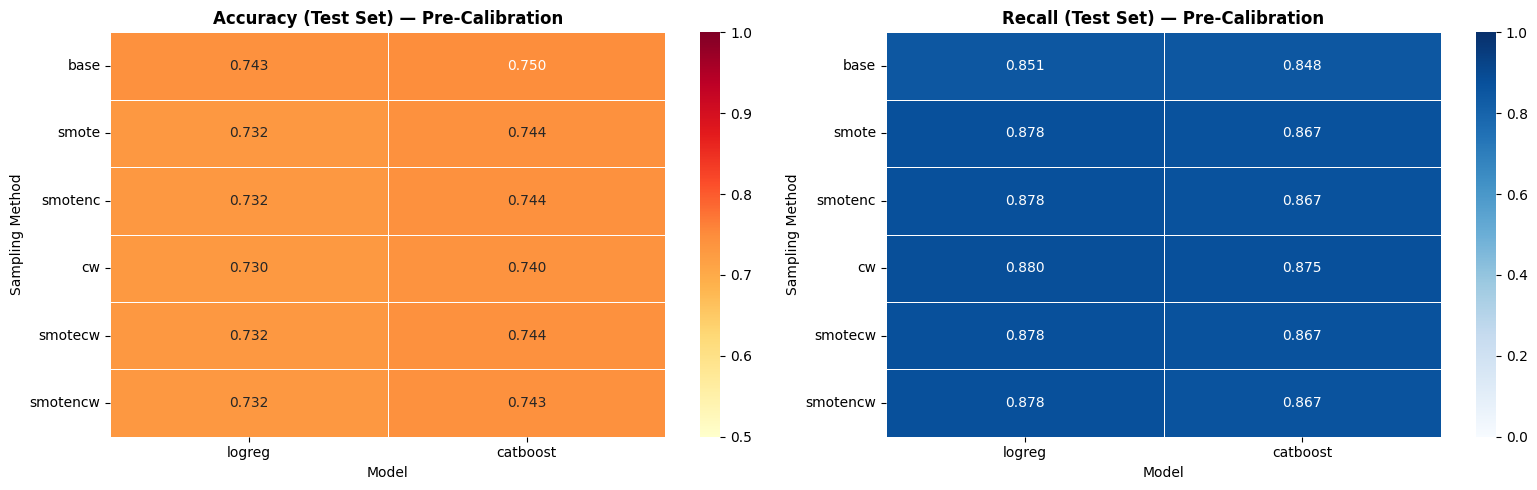

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/pre_cal_heatmaps.png


In [56]:
# ── EXP3 · Pre-Calibration Test-Set Metrics (all 36 models) ─────────────────

e3_pre_df = pd.DataFrame([r for r in e3_results if 'error' not in r])
e3_pre_df['combined'] = (e3_pre_df['accuracy'] + e3_pre_df['recall']) / 2.0
e3_pre_df = e3_pre_df.sort_values(['combined', 'auc'], ascending=False).reset_index(drop=True)
e3_pre_df.index += 1

print("=" * 80)
print("PRE-CALIBRATION TEST-SET METRICS  (sorted by 0.5·acc + 0.5·recall)")
print("=" * 80)
display(e3_pre_df[[
    'sampling', 'model', 'accuracy', 'recall', 'precision', 'f1', 'auc', 'logloss', 'ece', 'combined'
]])

# Save
_pre_path = E3_DIR / 'pre_calibration_results.csv'
e3_pre_df.to_csv(_pre_path, index=True, index_label='rank')
print(f"\nSaved: {_pre_path}")

# ── Heatmap: accuracy by sampling × model ────────────────────────────────────
pivot_acc = e3_pre_df.pivot_table(
    values='accuracy', index='sampling', columns='model', aggfunc='first')
pivot_acc = pivot_acc.reindex(index=SAMPLING_METHODS, columns=MODEL_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], vmin=0.5, vmax=1.0)
axes[0].set_title('Accuracy (Test Set) — Pre-Calibration', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Sampling Method')

pivot_rec = e3_pre_df.pivot_table(
    values='recall', index='sampling', columns='model', aggfunc='first')
pivot_rec = pivot_rec.reindex(index=SAMPLING_METHODS, columns=MODEL_NAMES)
sns.heatmap(pivot_rec, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=axes[1], vmin=0.0, vmax=1.0)
axes[1].set_title('Recall (Test Set) — Pre-Calibration', fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Sampling Method')

plt.tight_layout()
_hm_path = E3_DIR / 'plots' / 'pre_cal_heatmaps.png'
plt.savefig(_hm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {_hm_path}")


In [57]:
# ── EXP3 · Calibration: Base · Platt · Isotonic · Venn-Abers ────────────────
# Each of the 36 trained models is calibrated with all 4 methods (144 total).
# Calibrators are fit on the CAL split; metrics reported on the TEST split.

e3_cal_results = []        # post-calibration metrics
e3_cal_probs   = {}        # (sampling, model, cal_method) → y_te_proba

for (sampling, model_name), fitted_model in e3_models.items():
    p_cal   = fitted_model.predict_proba(X_e3_cal_proc)[:, 1]
    p_te    = fitted_model.predict_proba(X_e3_te_proc)[:, 1]

    for cal_method in CAL_METHODS:
        try:
            calibrator = e3_fit_calibrator(cal_method, p_cal, y_e3_cal)
            p_te_cal   = e3_apply_calibrator(cal_method, calibrator, p_te)

            m = e3_metrics(y_e3_te, p_te_cal)
            e3_cal_probs[(sampling, model_name, cal_method)] = p_te_cal

            e3_cal_results.append({
                'sampling':    sampling,
                'model':       model_name,
                'calibration': cal_method,
                **{k: round(v, 4) for k, v in m.items()},
            })
        except Exception as exc:
            e3_cal_results.append({
                'sampling':    sampling,
                'model':       model_name,
                'calibration': cal_method,
                'error':       str(exc),
            })

print(f"Calibration complete — {len(e3_cal_results)} entries (expected 144).")


Calibration complete — 72 entries (expected 144).


POST-CALIBRATION TEST-SET METRICS  (sorted by 0.5·acc + 0.5·recall)
Calibration metrics highlighted: ECE (lower=better)  |  LogLoss (lower=better)


,sampling,model,calibration,accuracy,recall,precision,f1,auc,logloss,ece,combined
1,cw,catboost,base,0.7522,0.8460,0.5920,0.6966,0.8477,0.4825,0.1008,0.7991
2,cw,lightgbm,base,0.7515,0.8464,0.5911,0.6961,0.8482,0.4819,0.1007,0.7990
3,cw,logreg,base,0.7541,0.8152,0.5986,0.6903,0.8405,0.4966,0.1057,0.7847
4,smote,logreg,base,0.7545,0.8125,0.5995,0.6899,0.8406,0.4960,0.1035,0.7835
5,smotenc,logreg,base,0.7545,0.8125,0.5995,0.6899,0.8406,0.4960,0.1035,0.7835
...,...,...,...,...,...,...,...,...,...,...,...
68,smotencw,logreg,platt,0.7688,0.6559,0.6562,0.6560,0.8406,0.4617,0.0255,0.7124
69,cw,logreg,platt,0.7684,0.6546,0.6559,0.6552,0.8405,0.4616,0.0250,0.7115
70,cw,logreg,venn_abers,0.7678,0.6460,0.6574,0.6517,0.8402,0.4583,0.0114,0.7069
71,cw,logreg,isotonic,0.7680,0.6456,0.6579,0.6517,0.8402,0.4595,0.0114,0.7068



Saved: /workspace/Thesis-part-2/exp3_logreg_cat/post_calibration_results.csv


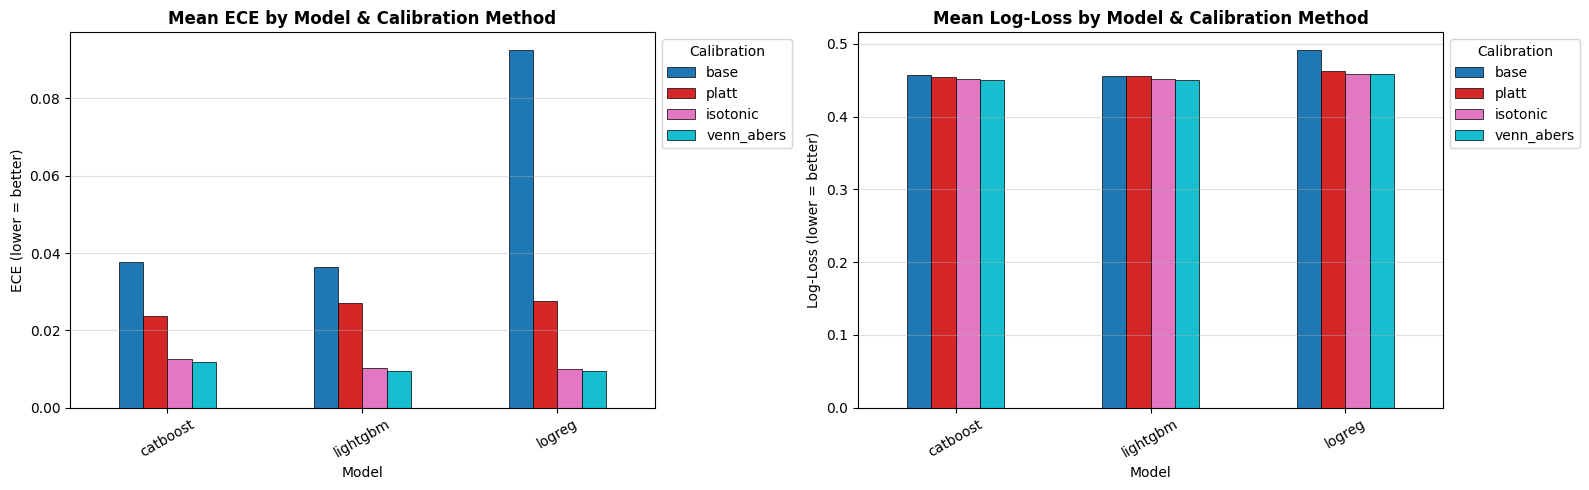

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/post_cal_ece_logloss.png

Best model: catboost  |  sampling: cw  |  calibration: base
  acc=0.7522  rec=0.8460  auc=0.8477  ece=0.1008  logloss=0.4825


In [58]:
# ── EXP3 · Post-Calibration Test-Set Metrics + ECE / Log-Loss ───────────────

e3_cal_df = pd.DataFrame([r for r in e3_cal_results if 'error' not in r])
e3_cal_df['combined'] = (e3_cal_df['accuracy'] + e3_cal_df['recall']) / 2.0
e3_cal_df = e3_cal_df.sort_values(['combined', 'auc'], ascending=False).reset_index(drop=True)
e3_cal_df.index += 1

print("=" * 90)
print("POST-CALIBRATION TEST-SET METRICS  (sorted by 0.5·acc + 0.5·recall)")
print("Calibration metrics highlighted: ECE (lower=better)  |  LogLoss (lower=better)")
print("=" * 90)
display(e3_cal_df[[
    'sampling', 'model', 'calibration',
    'accuracy', 'recall', 'precision', 'f1', 'auc',
    'logloss', 'ece', 'combined'
]])

# Save
_cal_path = E3_DIR / 'post_calibration_results.csv'
e3_cal_df.to_csv(_cal_path, index=True, index_label='rank')
print(f"\nSaved: {_cal_path}")

# ── ECE comparison bar chart ──────────────────────────────────────────────────
ece_pivot = e3_cal_df.pivot_table(
    values='ece', index='model', columns='calibration', aggfunc='mean')
ece_pivot = ece_pivot.reindex(columns=CAL_METHODS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ece_pivot.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='black', linewidth=0.5)
axes[0].set_title('Mean ECE by Model & Calibration Method', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('ECE (lower = better)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Calibration', bbox_to_anchor=(1, 1))
axes[0].grid(axis='y', alpha=0.4)

ll_pivot = e3_cal_df.pivot_table(
    values='logloss', index='model', columns='calibration', aggfunc='mean')
ll_pivot = ll_pivot.reindex(columns=CAL_METHODS)
ll_pivot.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='black', linewidth=0.5)
axes[1].set_title('Mean Log-Loss by Model & Calibration Method', fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Log-Loss (lower = better)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Calibration', bbox_to_anchor=(1, 1))
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
_ece_path = E3_DIR / 'plots' / 'post_cal_ece_logloss.png'
plt.savefig(_ece_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {_ece_path}")

# ── Identify best overall calibrated model ───────────────────────────────────
best_cal_row = e3_cal_df.iloc[0]
e3_best_key  = (best_cal_row['sampling'], best_cal_row['model'])
e3_best_model  = e3_models[e3_best_key]
e3_best_cal_m  = best_cal_row['calibration']
e3_best_sample = best_cal_row['sampling']
e3_best_mname  = best_cal_row['model']

print(f"\nBest model: {e3_best_mname}  |  sampling: {e3_best_sample}"
      f"  |  calibration: {e3_best_cal_m}")
print(f"  acc={best_cal_row['accuracy']:.4f}  rec={best_cal_row['recall']:.4f}"
      f"  auc={best_cal_row['auc']:.4f}  ece={best_cal_row['ece']:.4f}"
      f"  logloss={best_cal_row['logloss']:.4f}")


Building SHAP explainer for: catboost  (sampling=cw)
SHAP values shape: (300, 38)


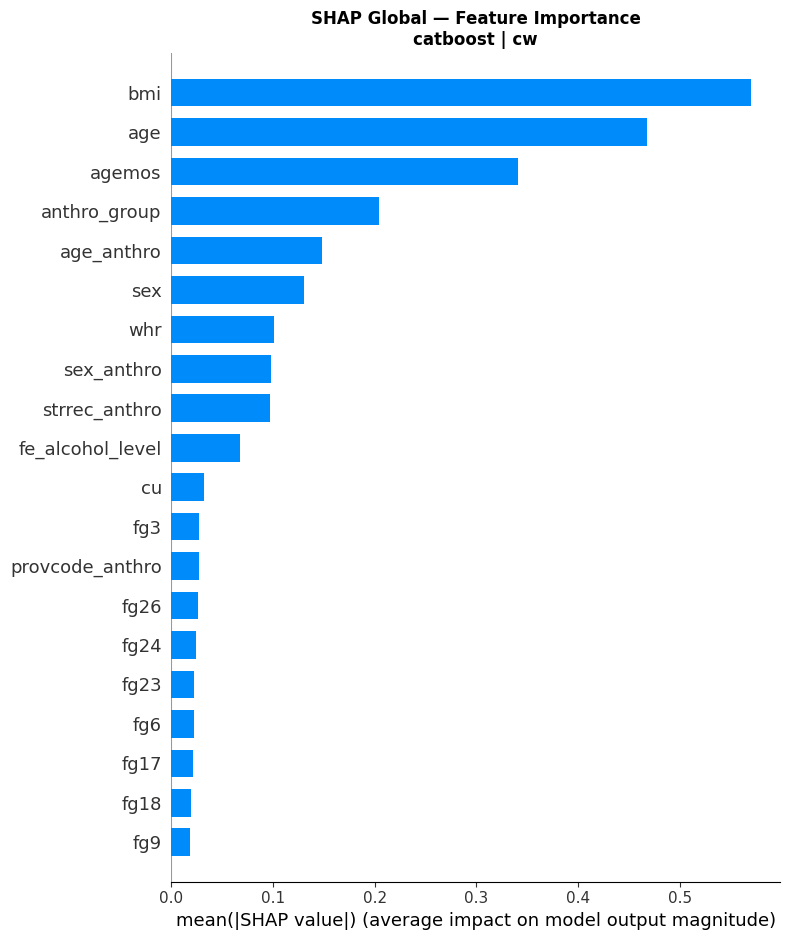

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/shap_global_bar.png


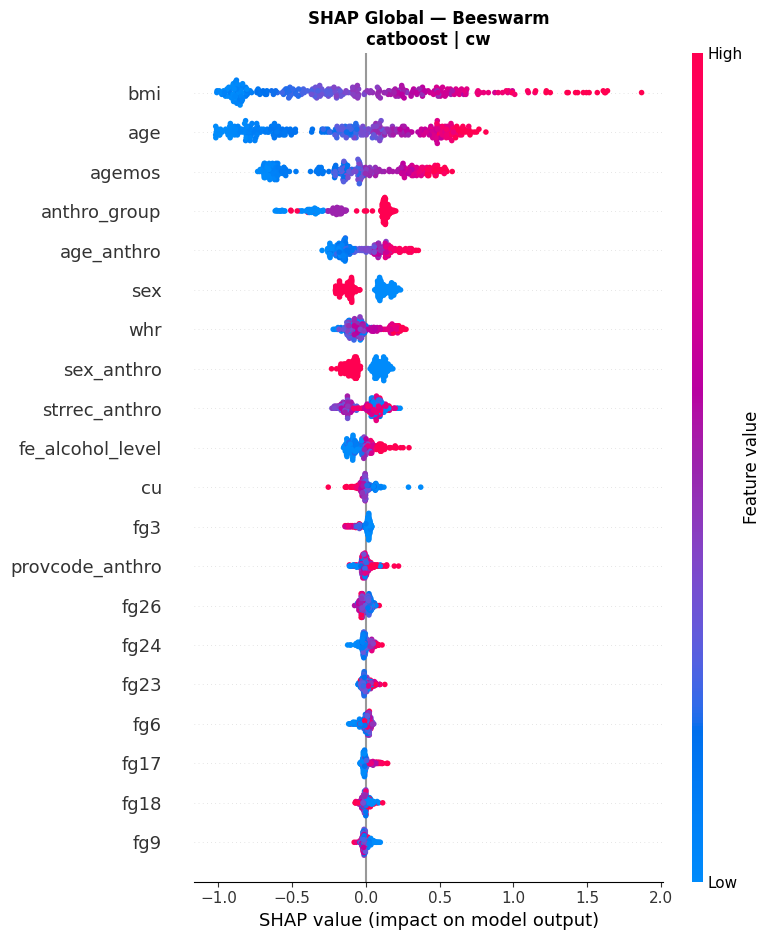

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/shap_global_beeswarm.png


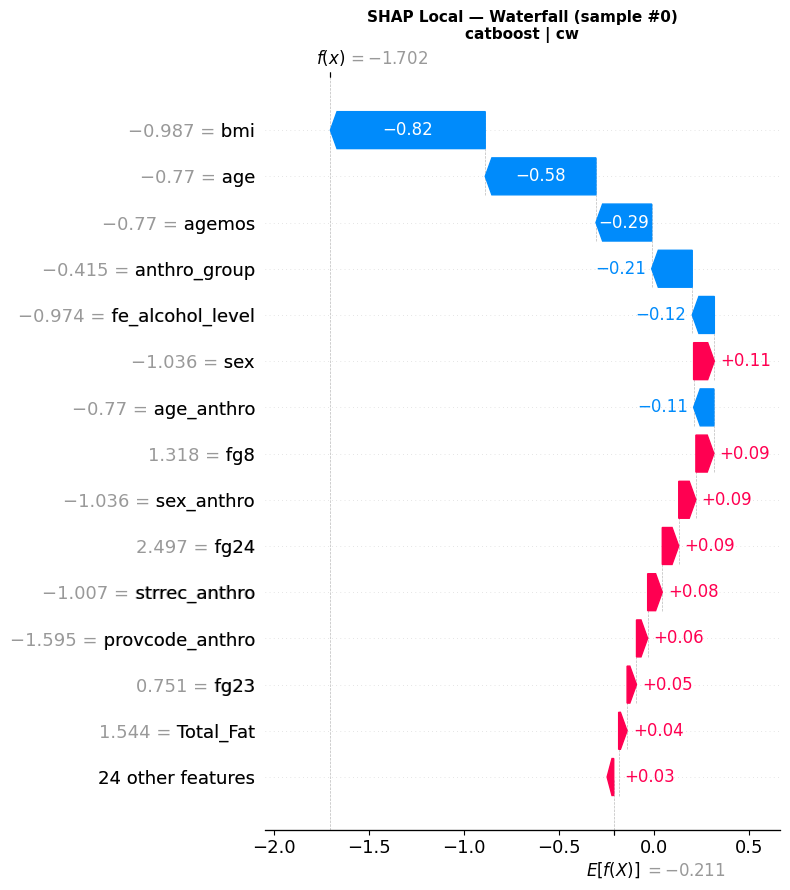

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/shap_local_waterfall.png


In [59]:
# ── EXP3 · SHAP Global + Local Explanation ──────────────────────────────────
# Best model identified in the previous cell (e3_best_model / e3_best_mname)

_SHAP_TEST_N   = 300   # number of test samples for global SHAP
_SHAP_BG_N     = 100   # background samples for non-tree explainers

X_e3_te_shap = X_e3_te_proc[:_SHAP_TEST_N]
feat_arr_e3  = np.array(e3_feat_names)

# ── Build SHAP explainer (auto-select by model type) ─────────────────────────
X_bg = e3_tr_data[e3_best_key][0][:_SHAP_BG_N]   # processed train background

print(f"Building SHAP explainer for: {e3_best_mname}  (sampling={e3_best_sample})")

_tree_types = ('catboost', 'xgboost', 'randomforest', 'adaboost')

try:
    if e3_best_mname in _tree_types:
        _explainer = shap.TreeExplainer(e3_best_model)
    elif e3_best_mname == 'logreg':
        _explainer = shap.LinearExplainer(e3_best_model, X_bg)
    else:
        _explainer = shap.KernelExplainer(
            lambda x: e3_best_model.predict_proba(x)[:, 1], X_bg)

    _shap_raw = _explainer.shap_values(X_e3_te_shap)

    # Normalise to class-1 array (RF returns a list)
    if isinstance(_shap_raw, list):
        _sv   = np.array(_shap_raw[1])
        _ev   = (_explainer.expected_value[1]
                 if hasattr(_explainer.expected_value, '__len__')
                 else float(_explainer.expected_value))
    else:
        _sv = np.array(_shap_raw)
        _ev = (float(_explainer.expected_value[0])
               if hasattr(_explainer.expected_value, '__len__')
               else float(_explainer.expected_value))

    print(f"SHAP values shape: {_sv.shape}")

    # ── GLOBAL — Bar chart (mean |SHAP|) ─────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(_sv, X_e3_te_shap, feature_names=feat_arr_e3,
                      plot_type='bar', show=False, max_display=20)
    plt.title(f"SHAP Global — Feature Importance\n"
              f"{e3_best_mname} | {e3_best_sample}", fontweight='bold', fontsize=12)
    plt.tight_layout()
    _bar_path = E3_DIR / 'plots' / 'shap_global_bar.png'
    plt.savefig(_bar_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {_bar_path}")

    # ── GLOBAL — Beeswarm ────────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(_sv, X_e3_te_shap, feature_names=feat_arr_e3,
                      show=False, max_display=20)
    plt.title(f"SHAP Global — Beeswarm\n"
              f"{e3_best_mname} | {e3_best_sample}", fontweight='bold', fontsize=12)
    plt.tight_layout()
    _bees_path = E3_DIR / 'plots' / 'shap_global_beeswarm.png'
    plt.savefig(_bees_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {_bees_path}")

    # ── LOCAL — Waterfall for one HTN-positive test sample ───────────────────
    _pos_indices = np.where(y_e3_te[:_SHAP_TEST_N] == 1)[0]
    _local_idx   = int(_pos_indices[0]) if len(_pos_indices) else 0

    _exp_local = shap.Explanation(
        values       = _sv[_local_idx],
        base_values  = _ev,
        data         = X_e3_te_shap[_local_idx],
        feature_names= feat_arr_e3.tolist(),
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(_exp_local, show=False, max_display=15)
    plt.title(f"SHAP Local — Waterfall (sample #{_local_idx})\n"
              f"{e3_best_mname} | {e3_best_sample}", fontweight='bold', fontsize=11)
    plt.tight_layout()
    _wf_path = E3_DIR / 'plots' / 'shap_local_waterfall.png'
    plt.savefig(_wf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {_wf_path}")

    # ── LOCAL — Force plot (inline HTML) ─────────────────────────────────────
    shap.initjs()
    _force = shap.force_plot(
        _ev,
        _sv[_local_idx],
        X_e3_te_shap[_local_idx],
        feature_names=feat_arr_e3.tolist(),
    )
    display(_force)

except Exception as _shap_exc:
    print(f"SHAP failed: {_shap_exc}")
    print("Tip: try re-running after restarting the kernel if OOM or import issues occur.")


LIME explanation for test sample #0
True label : HTN
Predicted probability (HTN): 0.1542



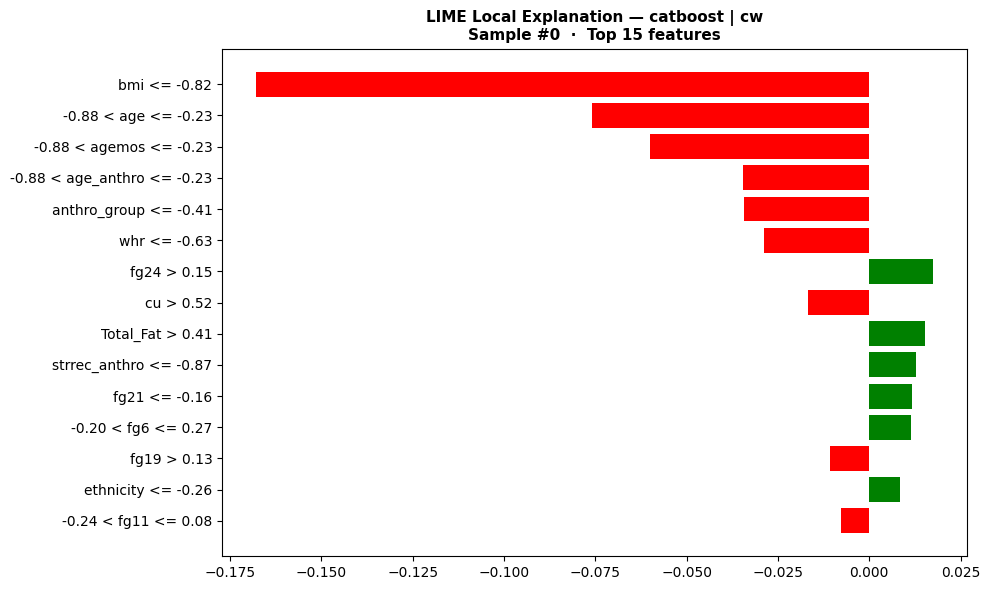

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/lime_local.png


,Feature Condition,LIME Weight,|Weight|
1,bmi <= -0.82,-0.1679,0.1679
2,-0.88 < age <= -0.23,-0.0759,0.0759
3,-0.88 < agemos <= -0.23,-0.0601,0.0601
4,-0.88 < age_anthro <= -0.23,-0.0345,0.0345
5,anthro_group <= -0.41,-0.0343,0.0343
6,whr <= -0.63,-0.0289,0.0289
7,fg24 > 0.15,0.0175,0.0175
8,cu > 0.52,-0.0168,0.0168
9,Total_Fat > 0.41,0.0152,0.0152
10,strrec_anthro <= -0.87,0.0128,0.0128



EXP3 complete.
All plots saved to: /workspace/Thesis-part-2/exp3_logreg_cat/plots
Results CSVs  saved to: /workspace/Thesis-part-2/exp3_logreg_cat


In [60]:
# ── EXP3 · LIME Local Explanation ───────────────────────────────────────────
# Explains the same sample used in the SHAP local plot above.

_LIME_FEATURES = 15   # top features to display

_X_train_bg = e3_tr_data[e3_best_key][0]   # processed training data (numpy)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = _X_train_bg,
    feature_names  = e3_feat_names,
    class_names    = ['No HTN', 'HTN'],
    mode           = 'classification',
    random_state   = E3_SEED,
    discretize_continuous = True,
)

def _pred_fn(X):
    return e3_best_model.predict_proba(X)

# Explain the same positive instance used for SHAP local
_lime_idx = _local_idx if '_local_idx' in dir() else 0

lime_exp = lime_explainer.explain_instance(
    data_row    = X_e3_te_proc[_lime_idx],
    predict_fn  = _pred_fn,
    num_features= _LIME_FEATURES,
    labels      = (1,),
)

# ── Inline display ────────────────────────────────────────────────────────────
print(f"LIME explanation for test sample #{_lime_idx}")
print(f"True label : {'HTN' if y_e3_te[_lime_idx] == 1 else 'No HTN'}")
print(f"Predicted probability (HTN): "
      f"{e3_best_model.predict_proba(X_e3_te_proc[[_lime_idx]])[0, 1]:.4f}")
print()

fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(10, 6)
plt.title(
    f"LIME Local Explanation — {e3_best_mname} | {e3_best_sample}\n"
    f"Sample #{_lime_idx}  ·  Top {_LIME_FEATURES} features",
    fontweight='bold', fontsize=11)
plt.tight_layout()
_lime_path = E3_DIR / 'plots' / 'lime_local.png'
plt.savefig(_lime_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {_lime_path}")

# ── Text table ────────────────────────────────────────────────────────────────
lime_pairs = lime_exp.as_list(label=1)
lime_table = pd.DataFrame(lime_pairs, columns=['Feature Condition', 'LIME Weight'])
lime_table['|Weight|'] = lime_table['LIME Weight'].abs()
lime_table = lime_table.sort_values('|Weight|', ascending=False).reset_index(drop=True)
lime_table.index += 1
display(lime_table)

# ── Notebook-rendered HTML version ───────────────────────────────────────────
try:
    lime_exp.show_in_notebook(show_table=True, show_all=False)
except Exception:
    pass

print("\nEXP3 complete.")
print(f"All plots saved to: {E3_DIR / 'plots'}")
print(f"Results CSVs  saved to: {E3_DIR}")
